In [18]:
import os 
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import csv, random
import time
from pathlib import Path
import pandas as pd
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator


In [19]:
def build_sam_model(model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml",
                    sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt", 
                    device=None):
     
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    sam2 = build_sam2(str(Path(model_cfg)), str(Path(sam2_checkpoint)), device=device, apply_postprocessing=False)

    return sam2

In [20]:
def create_mask_generator(model):
    mask_generator_2 = SAM2AutomaticMaskGenerator(
        model=model,
        points_per_side=96,
        points_per_batch=128,
        pred_iou_thresh=0.5,
        stability_score_thresh=0.92,
        stability_score_offset=0.6,
        crop_n_layers=1,
        box_nms_thresh=0.8,
        crop_n_points_downscale_factor=2,
        min_mask_region_area=50.0,
        use_m2m=True,
    )

    return mask_generator_2

In [21]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

In [22]:
def load_png_as_rgb(png_path):
    with Image.open(png_path) as img:
        img = img.convert("RGB")
        arr = np.array(img, dtype=np.uint8)

    assert arr.ndim == 3 and arr.shape[2] == 3
    assert arr.dtype == np.uint8
    return arr

In [23]:
def get_data_root():
    return Path.home() / "skimage_segmentation"

In [24]:
def load_rows_from_csv(csv_path):
    with csv_path.open(newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    return rows

In [25]:
def water_fraction_from_npz(npz_path):
    d = np.load(npz_path)
    m = d["ice_mask"].astype(bool)

    return float(m.mean())

In [26]:
def select_good_idxs(rows, min_fraction=0.05, max_fraction=0.95):
    good_idxs = []
    for idx in range(len(rows)):
        npz_path = rows[idx]["npz_path"].strip()
        try:
            f = water_fraction_from_npz(npz_path)
        except Exception:
            continue
        if min_fraction < f < max_fraction:
            good_idxs.append(idx)

    idxs = good_idxs if len(good_idxs) > 0 else list(range(len(rows)))
    print('good idxs:', idxs[:30])
    
    return idxs   

In [27]:
def run_sam_on_samples(rows, test_idxs, mask_generator, data_root):
    raw_results = []

    for idx in test_idxs:
        png_path = data_root / rows[idx]["png_path"].strip()
        npz_path = data_root / rows[idx]["npz_path"].strip()

        image = load_png_as_rgb(png_path)

        data = np.load(npz_path)
        ice_mask = data["ice_mask"]

        t0 = time.perf_counter()
        masks = mask_generator.generate(image)
        t_generate = time.perf_counter() - t0

        raw_results.append({
            "idx": idx,
            "image": image,
            "masks": masks,
            "ice_mask": ice_mask,
            "generate_time": t_generate,
        })

        print("masks:", len(masks))
        if len(masks) > 0:
            print("keys:", masks[0].keys())
        print("ice_mask unique:", np.unique(ice_mask))
        print("ice pixels:", (~ice_mask).sum())
        print("water pixels:", ice_mask.sum())
        print("generate time:", t_generate)

    return raw_results

In [28]:
def show_sam_result(raw_results, borders=True):
    fig, axes = plt.subplots(3, 1, figsize=(8, 24))

    for row, item in enumerate(raw_results):
        image = item["image"]
        masks = item["masks"]
        idx = item["idx"]

        axes[row].imshow(image)
        plt.sca(axes[row])
        show_anns(masks, borders=borders)

        axes[row].set_title(f"SAM2 idx={idx} | masks={len(masks)}")
        axes[row].axis("off")

    plt.show()

In [29]:
def build_prediction_map(masks, ice_mask):
    h, w = ice_mask.shape
    sam2_pred = np.full((h, w), -1, dtype=np.int8)

    masks_sorted = sorted(masks, key=lambda x: x["area"], reverse=True)
    water_mask = ice_mask.astype(bool)

    for ann in masks_sorted:
        mask = ann["segmentation"]

        if mask.sum() == 0:
            continue

        water_fraction = water_mask[mask].mean()
        sam2_pred[mask] = 1 if water_fraction > 0.5 else 0

    return sam2_pred

In [30]:
def compute_prediction_stats(sam2_pred, ice_mask):
    valid = sam2_pred != -1
    errors = (sam2_pred != ice_mask.astype(np.int8)) & valid
    unseg = sam2_pred == -1

    pred_water = (sam2_pred == 1).sum()
    pred_ice = (sam2_pred == 0).sum()
    unk = (sam2_pred == -1).sum()

    return {
        "errors": errors,
        "unseg": unseg,
        "pred_water": pred_water,
        "pred_ice": pred_ice,
        "unk": unk,
    }

In [31]:
def analyze_sample(item):
    sam2_pred = build_prediction_map(item["masks"], item["ice_mask"])
    stats = compute_prediction_stats(sam2_pred, item["ice_mask"])

    return {
        "idx": item["idx"],
        "image": item["image"],
        "masks": item["masks"],
        "ice_mask": item["ice_mask"],
        "sam2_pred": sam2_pred,
        **stats,
    }

In [32]:
def plot_prediction_comparison(item):
        image = item["image"]
        ice_mask = item["ice_mask"]
        sam2_pred = item["sam2_pred"]
        idx = item["idx"]

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(image)
        plt.title(f"Image idx={idx}")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(ice_mask, cmap="gray")
        plt.title("ice_mask")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(sam2_pred, cmap="gray", vmin=-1, vmax=1)
        plt.title("SAM2")
        plt.axis("off")

        plt.show()

In [33]:
def plot_error_maps(item):
        errors = item['errors']
        unseg = item['unseg']

        plt.figure(figsize=(12,8))

        plt.subplot(1,2,1)
        plt.imshow(errors, cmap="gray")
        plt.title("classification error on covered pixels")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(unseg, cmap="gray")
        plt.title("unclassified pixels")
        plt.axis("off")

        plt.show()

masks: 93
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 76333
water pixels: 185811
generate time: 95.54969092500141
masks: 27
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 116190
water pixels: 145954
generate time: 95.87174723600037
masks: 44
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 22206
water pixels: 239938
generate time: 96.40770641500058


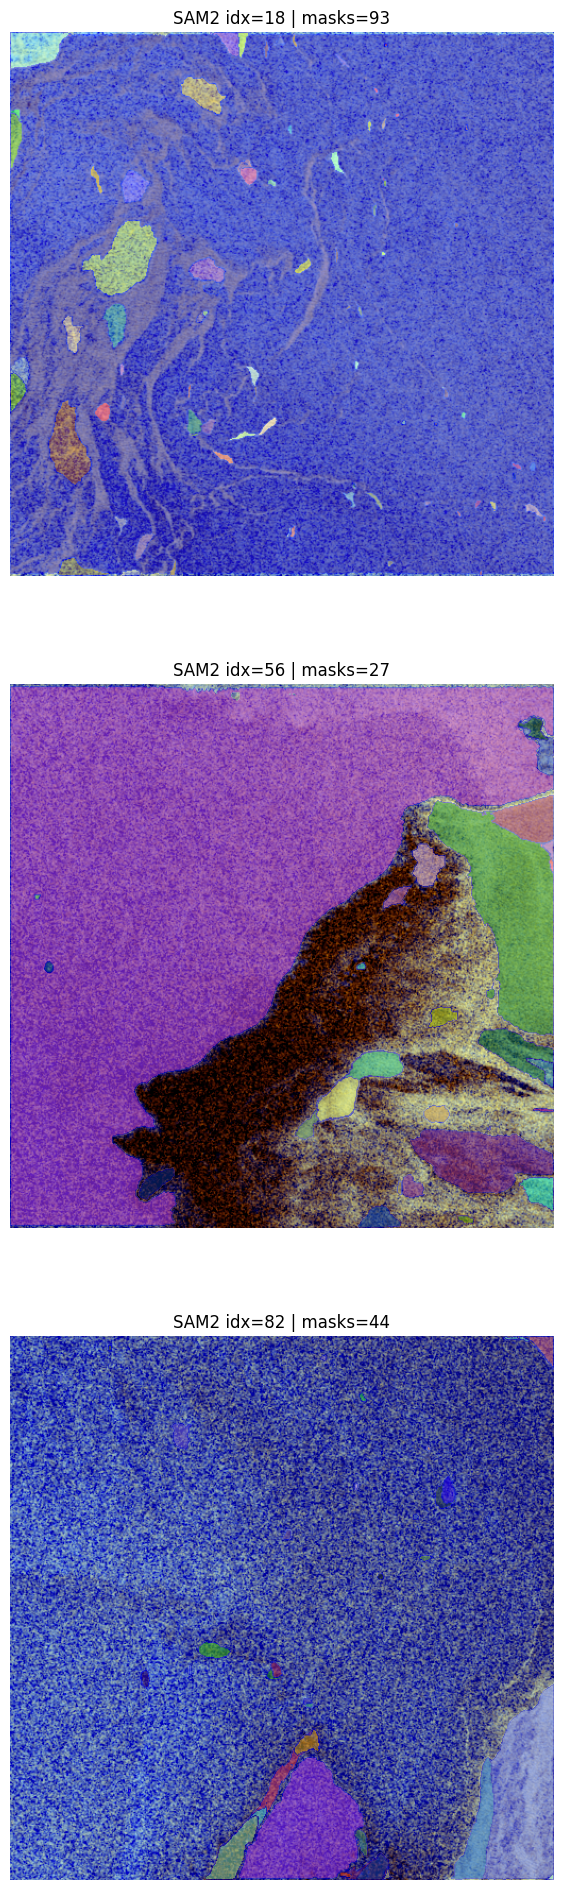

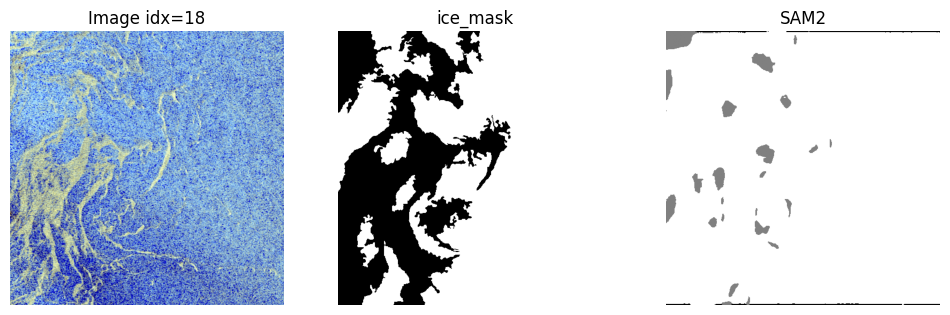

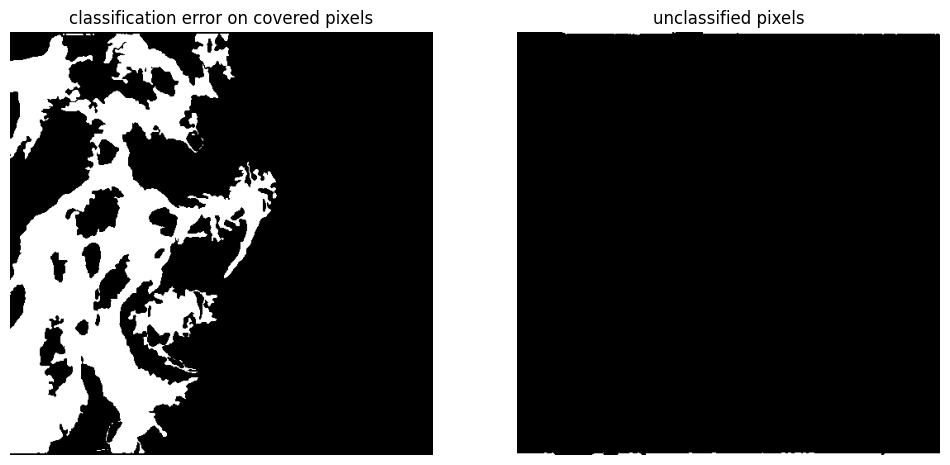

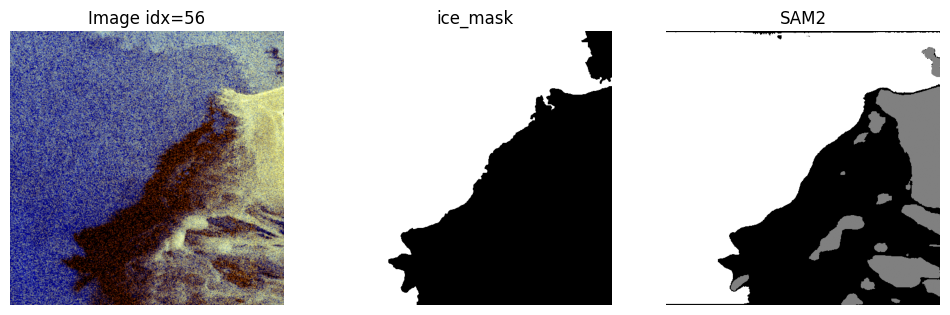

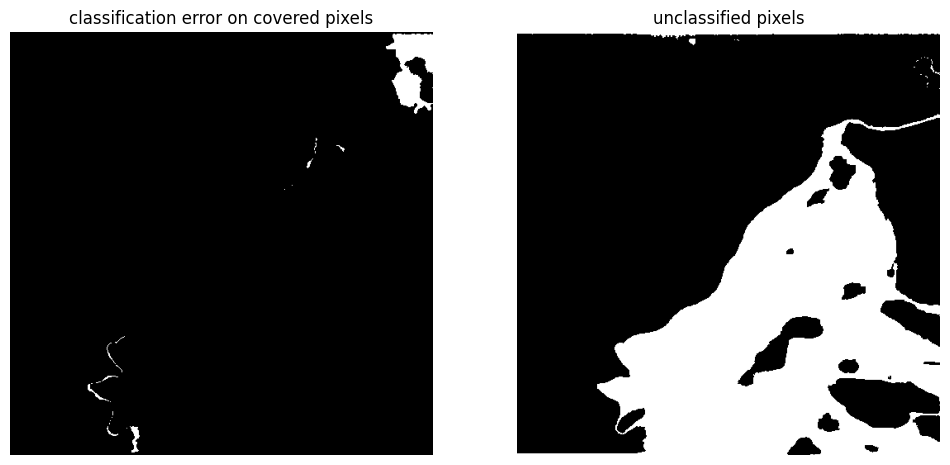

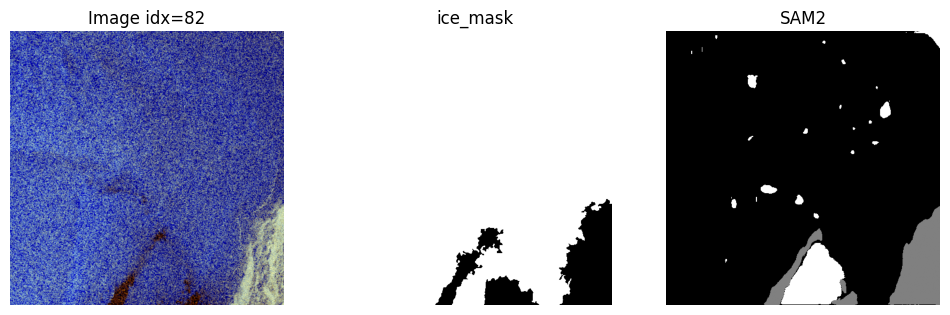

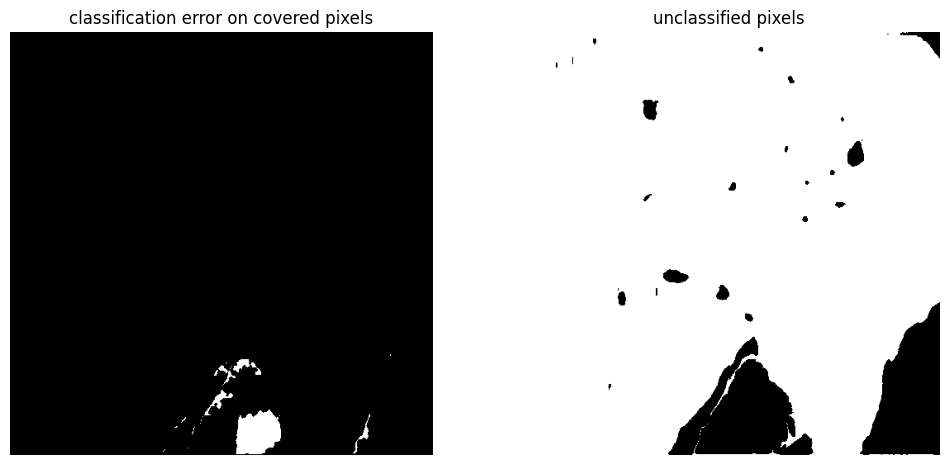

In [34]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    sam2 = build_sam_model(device=device)
    mask_generator = create_mask_generator(sam2)

    data_root = get_data_root()
    csv_path = data_root / "paired.csv"
    rows = load_rows_from_csv(csv_path)
    test_idxs = [18, 56, 82]

    raw_results = run_sam_on_samples(rows, test_idxs, mask_generator, data_root)

    analyzed_results = []
    for item in raw_results:
        analyzed = analyze_sample(item)
        analyzed_results.append(analyzed)

    show_sam_result(raw_results)

    for item in analyzed_results:
        plot_prediction_comparison(item)
        plot_error_maps(item)

if __name__ == "__main__":
    main()